# To check RF position to QDSPY coordinate transrom

### imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display



In [3]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs
  table_parameters:
    PreprocessParams:
      fs_resample: 60
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true
      pre_blur_sigma_s: 0.0
      post_blur_sigma_s: 0.0
paths:
  repo_directory: /gpfs01/euler/User/

In [4]:
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper
from simulations.loop_components.recording_file_copier import copy_rec_files,create_directory_structure
#from simulations.loop_components.stimulus import create_rf_avi_from_roi_ids


### Create processing components (connect them to DB)

In [5]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )



In [6]:

# Load config and tables
dj_table_holder.load_config()
dj_table_holder.load_tables()
print(" loaded and configured successfully")
# dj_table_holder.clear_tables("experiment")

# dj_table_holder.setup()




[2025-08-14 13:54:05,323][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-08-14 13:54:05,379][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop
 loaded and configured successfully


In [7]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)


quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)


random_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    model_configs=cfg.model_configs, 
    seeds= [123,456,789])

## During the experimet

### Move files from server to the repo 

In [8]:
create_directory_structure(base_directory= cfg.DJ.userinfo.data_dir,
                           date=  cfg.data_subfolders.day, 
                           experiment = cfg.data_subfolders.experiment)

copy_rec_files(
    recording_files_dir=cfg.paths.recording_files_dir,  # type: ignore
    destination_base=cfg.DJ.userinfo.data_dir,  # type: ignore
    date=cfg.data_subfolders.day,  # type: ignore
    experiment=cfg.data_subfolders.experiment,  # type: ignore
    full_dummy_ini_dir= os.path.join(cfg.paths.repo_directory, cfg.paths.dummy_ini_dir),  # type: ignore
)

SKIPPING File M1_RR_od.smh: does not match any permissible stimulus type.
SKIPPING File M1_RR_od.smp: does not match any permissible stimulus type.
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_chirp_1.smp to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/Raw/M1_RR_GCL1_chirp_1_iter0.smp
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_MB_1.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/Raw/M1_RR_GCL1_MB_1_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_chirp_1.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/Raw/M1_RR_GCL1_chirp_1_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_DN_1.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_r

In [11]:
preprocessor.upload_iteration_metadata()

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1
		header_name: 20250717_left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 7, 17, 0, 0), 'exp_num': 1}


OpticDisk: 100%|██████████| 1/1 [00:00<00:00, 40.41it/s]


Found 3 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 7, 17), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': '1', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 7, 17), 'exp_num': 1, 'raw_id': 1}`


Processes: 100%|██████████| 6/6 [00:03<00:00,  1.56it/s]


### Analysis and Visualization

In [12]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
field_key = missing_keys[0]
missing_keys
# import datetime
# test_key = {'experimenter': 'closedlooptest',
#   'date': datetime.date(2025, 7, 17),
#   'exp_num': 1,
#   'raw_id': 1,
#   'field': 'GCL1',
#   'region': 'RR',
#   'cond1': 'iter0'}
# missing_keys = [test_key]

[{'experimenter': 'closedlooptest',
  'date': datetime.date(2025, 7, 17),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL1',
  'region': 'RR',
  'cond1': '1'}]

In [13]:
# somehow I get a circular import error if I import this at the top
from simulations.gui.integrated_autorois import InteractiveRoiCanvas

In [ ]:
online_analysis_gui = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper,random_seed_mei_wrapper],
    field_key=field_key,
    canvas_width=30,
    )

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


In [15]:
display(online_analysis_gui.start_gui()) 

# Look at sRF peak and postition 

In [7]:
# show the first frame of Dnoise
import h5py
import matplotlib.pyplot as plt 
with h5py.File("/gpfs01/euler/data/Resources/Stimulus/noise.h5", "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)

In [45]:
def plot_srf_pos(roi_id = 27,ax = None):

    params = (dj_table_holder("FitGauss2DRF")() & dict(roi_id=roi_id)).fetch1("srf_params")
    
    #flipping because qdspy
    x,y = params["y_mean"], params["x_mean"]

    # (dj_table_holder('SplitRF')() & {'roi_id': roi_id}).plot1()
    sRF = (dj_table_holder('SplitRF')() & {'roi_id': roi_id}).fetch1('srf')

    print("peakx", x,"\npeaky", y)
    if ax is None:
        fig,ax = plt.subplots(1, 1, figsize=(5, 5))

    ax.imshow(noise_stimulus [0],origin='lower')
    ax.imshow(sRF, origin='lower', alpha=0.5, cmap='grey')
    ax.scatter( y,x, color='red', s=20, label='Peak Position')

peakx 10.9910893361754 
peaky 6.902242776125266
peakx 10.833540341009579 
peaky 6.139457151340813
peakx 12.029140284416554 
peaky 8.117229617889057
peakx 10.704898236864933 
peaky 7.2162035958768715
peakx 10.274709248252908 
peaky 6.9736971709146784
peakx 10.219808167176495 
peaky 7.283616912014812
peakx 8.889646089647972 
peaky 8.20692611403476
peakx 10.704244276150732 
peaky 7.238903162259263
peakx 8.784515447204054 
peaky 6.641778636830012
peakx 9.574119638520807 
peaky 7.1804217698599935
peakx 9.458331042064057 
peaky 6.5747737044180115
peakx 8.927677805631335 
peaky 8.160271172819035
peakx 8.68535362223673 
peaky 7.082428726556866
peakx 7.921552319845698 
peaky 8.13777036538643
peakx 7.934347594612261 
peaky 6.688822438195571


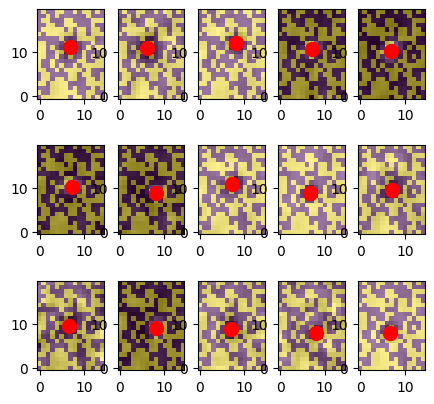

In [25]:
rois = [3, 4, 11, 21, 33, 35, 42, 47, 62, 66, 71, 78, 80, 86, 87]
fig,ax = plt.subplots(3, 5, figsize=(5, 5))
ax = ax.flatten()
# roi 27 has nice RF look at peak position
for r in rois:
    plot_srf_pos(r,ax=ax[rois.index(r)])

peakx 10.321889350021264 
peaky 6.745236770082847


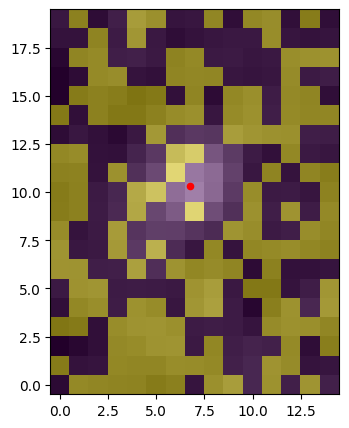

In [46]:
plot_srf_pos(44)

peakx 12.029140284416554 
peaky 8.117229617889057


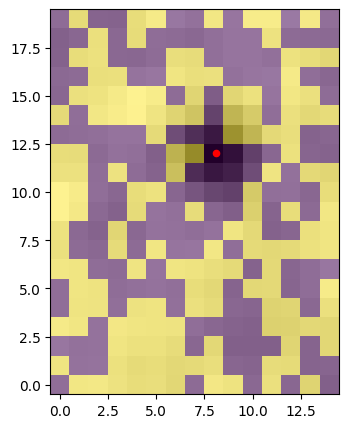

In [47]:
plot_srf_pos(11)

peakx 19.895483139662154 
peaky 13.91309686668065


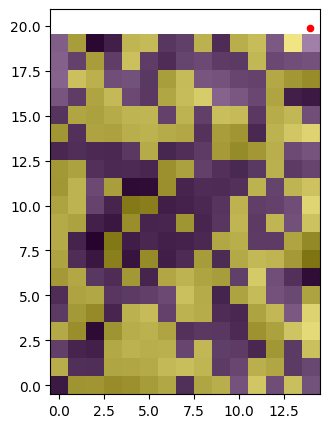

In [52]:
plot_srf_pos(97)

In [42]:
from typing import Tuple, List
def transform_to_qdspy_coord(stimulus_table,all_x_pix: List[float], all_y_pix: List[float]) -> List[Tuple[float, float]]:
    """
    transforms indices of dense noise to QDSpy coordinates in microns.
    x_pix values are AXIS 0 in DENSE NOISE 
    y_pix values are AXIS 1 in DENSE NOISE
    """
    
    # Get stimulus parameters
    stim_query = stimulus_table & {'stim_family': 'noise'}
    stim_dict = stim_query.fetch1('stim_dict')

    # Get pixel size and offset
    pixel_size_x_um = stim_dict['pix_scale_x_um']
    pixel_size_y_um = stim_dict['pix_scale_y_um']

    # What about offset? in stim dict?
    offset_x_um = stim_dict['offset_x_um']
    offset_y_um = stim_dict['offset_y_um']

    # get number of pixels in x and y
    pix_n_x, pix_n_y = stim_dict["pix_n_x"],stim_dict["pix_n_y"]
    
    # RF center relative to stimcenter (assume centered noise presentation)
    # we need to further subtract one by the pixels to that it is in index 0 base
    x_center_pix = (pix_n_x - 1) / 2
    y_center_pix = (pix_n_y - 1) / 2

    if  isinstance(all_x_pix, (int, float)):
        # If single value is passed, convert to list
        all_x_pix_list = [all_x_pix]
    else:
        all_x_pix_list = all_x_pix

    if isinstance(all_y_pix, (int, float)):
        # If single value is passed, convert to list
        all_y_pix_list = [all_y_pix]
    else:
        all_y_pix_list = all_y_pix

    out_list = []
    for x_pix,y_pix in zip(all_x_pix_list, all_y_pix_list):

        # We need to add half a pixel because QDSpy coordinates are in the center of the pixel
        x_pix = x_pix - x_center_pix
        y_pix = y_pix - y_center_pix

        # Calculate position in microns
        x_um = int(x_pix * pixel_size_x_um) + offset_x_um
        y_um = int(y_pix * pixel_size_y_um) + offset_y_um  
        out_list.append((x_um, y_um)) 

    return out_list

In [44]:
x = 10.321889350021264 
y = 6.745236770082847
transform_to_qdspy_coord(dj_table_holder("Stimulus")(), all_x_pix=[x], all_y_pix=[y])

[(32, -10)]

In [48]:
x=12.029140284416554 
y =  8.117229617889057
transform_to_qdspy_coord(dj_table_holder("Stimulus")(), all_x_pix=[x], all_y_pix=[y])

[(101, 44)]

# In QDSpy the point appears also on the same part of the pattern so the conversion of coordinates is correct

In [54]:
(dj_table_holder("FitGauss2DRF")() & dict(roi_id=33)).fetch1("srf_params")

{'amplitude': 0.26013551882805547,
 'x_mean': 6.9736971709146784,
 'y_mean': 10.274709248252908,
 'x_stddev': 1.1195782664669898,
 'y_stddev': 1.5785941594830704,
 'theta': -0.44956010572317856}

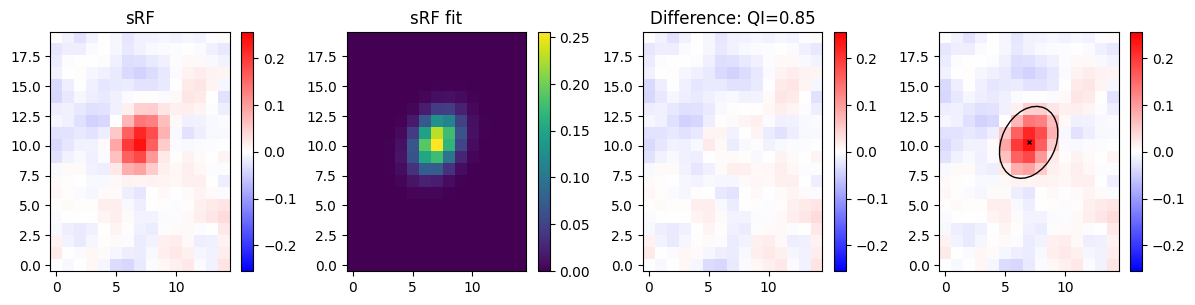

In [55]:
(dj_table_holder("FitGauss2DRF")() & dict(roi_id=33)).plot1()